# PointNet on ModelNet40 — v1 → v2 → v3 Ablation

## Why this notebook exists

ModelNet10 (10 pre-aligned classes) saturated for us at 0.9174 with v1 (minimal PointNet, no T-Net). Four experiments — v1, v1+aug, v2, v2+aug — failed to improve on it because (a) the test set is pre-aligned so T-Net has no real work to do, (b) the desk↔table / dresser↔night_stand confusions dominate the small class set, and (c) ModelNet10 has no canonical benchmark to chase. ModelNet40 (40 diverse classes) is the dataset the original PointNet paper actually benchmarks against, and it's where T-Net's contribution is supposed to manifest.


## Environment, imports setup

In [1]:
import os
import time
import zipfile
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers '3d' projection)
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Project paths — resolve defensively so the notebook works whether launched
# from project root or from notebooks/
_cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd

DATA_ROOT     = os.path.join(PROJECT_ROOT, "data")
DATA_DIR_M40  = os.path.join(DATA_ROOT, "ModelNet40")      # extracted dataset
ZIP_PATH_M40  = os.path.join(DATA_ROOT, "ModelNet40.zip")  # raw download
CACHE_DIR_M40 = os.path.join(DATA_ROOT, "cache_modelnet40_1024pts")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")

# Make sure parent folders exist
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(CACHE_DIR_M40, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print(f"Project root    : {PROJECT_ROOT}")
print(f"ModelNet40 dir  : {DATA_DIR_M40}")
print(f"  exists?       : {os.path.isdir(DATA_DIR_M40)}")
print(f"Cache dir       : {CACHE_DIR_M40}")
print(f"Checkpoints     : {CHECKPOINT_DIR}")

PyTorch version : 2.12.0
Device          : mps
Project root    : /Users/dosvatsky/3D Object Detection
ModelNet40 dir  : /Users/dosvatsky/3D Object Detection/data/ModelNet40
  exists?       : False
Cache dir       : /Users/dosvatsky/3D Object Detection/data/cache_modelnet40_1024pts
Checkpoints     : /Users/dosvatsky/3D Object Detection/checkpoints


#  Downloading and extracting ModelNet40

In [2]:
URLS_M40 = [
    "http://modelnet.cs.princeton.edu/ModelNet40.zip",
    "https://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet40.zip",
]


def download_with_progress(url, dest):
    """Download with a simple percentage progress bar that updates in place."""
    def hook(block_num, block_size, total_size):
        downloaded = block_num * block_size
        if total_size > 0:
            percent = min(100, downloaded * 100 / total_size)
            mb_done  = downloaded / 1024**2
            mb_total = total_size / 1024**2
            print(f"\r  {percent:5.1f}%  ({mb_done:7.1f} / {mb_total:7.1f} MB)", end="")
    urllib.request.urlretrieve(url, dest, reporthook=hook)
    print()  # newline after progress finishes


# ---- A. Download (skip if zip is already present and at least 1 GB) ----
if os.path.exists(ZIP_PATH_M40) and os.path.getsize(ZIP_PATH_M40) > 1e9:
    size_mb = os.path.getsize(ZIP_PATH_M40) / 1024**2
    print(f"Zip already exists at {ZIP_PATH_M40} ({size_mb:.1f} MB) -- skipping download")
else:
    print("Downloading ModelNet40.zip (about 1.7 GB)...")
    download_success = False
    for url in URLS_M40:
        try:
            print(f"  Trying: {url}")
            download_with_progress(url, ZIP_PATH_M40)
            download_success = True
            print(f"  OK: downloaded to {ZIP_PATH_M40}")
            break
        except Exception as e:
            print(f"  FAILED: {e}")
            if os.path.exists(ZIP_PATH_M40):
                os.remove(ZIP_PATH_M40)
    if not download_success:
        raise RuntimeError(
            "All Princeton URLs failed. Manually download ModelNet40.zip and place at:\n"
            f"  {ZIP_PATH_M40}\n"
            "Then re-run this cell."
        )


# ---- B. Extract (skip if a known class folder already exists) ----
if os.path.isdir(os.path.join(DATA_DIR_M40, "airplane")):
    print(f"\nModelNet40 already extracted at {DATA_DIR_M40} -- skipping extraction")
else:
    print(f"\nExtracting ModelNet40.zip to {DATA_ROOT}/ ...")
    with zipfile.ZipFile(ZIP_PATH_M40, "r") as zf:
        zf.extractall(DATA_ROOT)
    print(f"  OK: extracted to {DATA_DIR_M40}")


# ---- C. Verify class folders ----
class_folders = sorted([
    d for d in os.listdir(DATA_DIR_M40)
    if os.path.isdir(os.path.join(DATA_DIR_M40, d))
    and not d.startswith(("_", "."))
])
print(f"\nFound {len(class_folders)} class folders:")
for i, c in enumerate(class_folders):
    print(f"  {i:>2}  {c}")

assert len(class_folders) == 40, f"Expected 40 classes, found {len(class_folders)}"
print("\nModelNet40 ready.")

  Trying: http://modelnet.cs.princeton.edu/ModelNet40.zip
  100.0%  ( 1944.7 /  1944.7 MB)
  OK: downloaded to /Users/dosvatsky/3D Object Detection/data/ModelNet40.zip

Extracting ModelNet40.zip to /Users/dosvatsky/3D Object Detection/data/ ...
  OK: extracted to /Users/dosvatsky/3D Object Detection/data/ModelNet40

Found 40 class folders:
   0  airplane
   1  bathtub
   2  bed
   3  bench
   4  bookshelf
   5  bottle
   6  bowl
   7  car
   8  chair
   9  cone
  10  cup
  11  curtain
  12  desk
  13  door
  14  dresser
  15  flower_pot
  16  glass_box
  17  guitar
  18  keyboard
  19  lamp
  20  laptop
  21  mantel
  22  monitor
  23  night_stand
  24  person
  25  piano
  26  plant
  27  radio
  28  range_hood
  29  sink
  30  sofa
  31  stairs
  32  stool
  33  table
  34  tent
  35  toilet
  36  tv_stand
  37  vase
  38  wardrobe
  39  xbox

ModelNet40 ready.


## Inspecting dataset structure and class balance

idx  class            train    test   total
--------------------------------------------------
  0  airplane           626     100     726
  1  bathtub            106      50     156
  2  bed                515     100     615
  3  bench              173      20     193
  4  bookshelf          572     100     672
  5  bottle             335     100     435
  6  bowl                64      20      84
  7  car                197     100     297
  8  chair              889     100     989
  9  cone               167      20     187
 10  cup                 79      20      99
 11  curtain            138      20     158
 12  desk               200      86     286
 13  door               109      20     129
 14  dresser            200      86     286
 15  flower_pot         149      20     169
 16  glass_box          171     100     271
 17  guitar             155     100     255
 18  keyboard           145      20     165
 19  lamp               124      20     144
 20  laptop             1

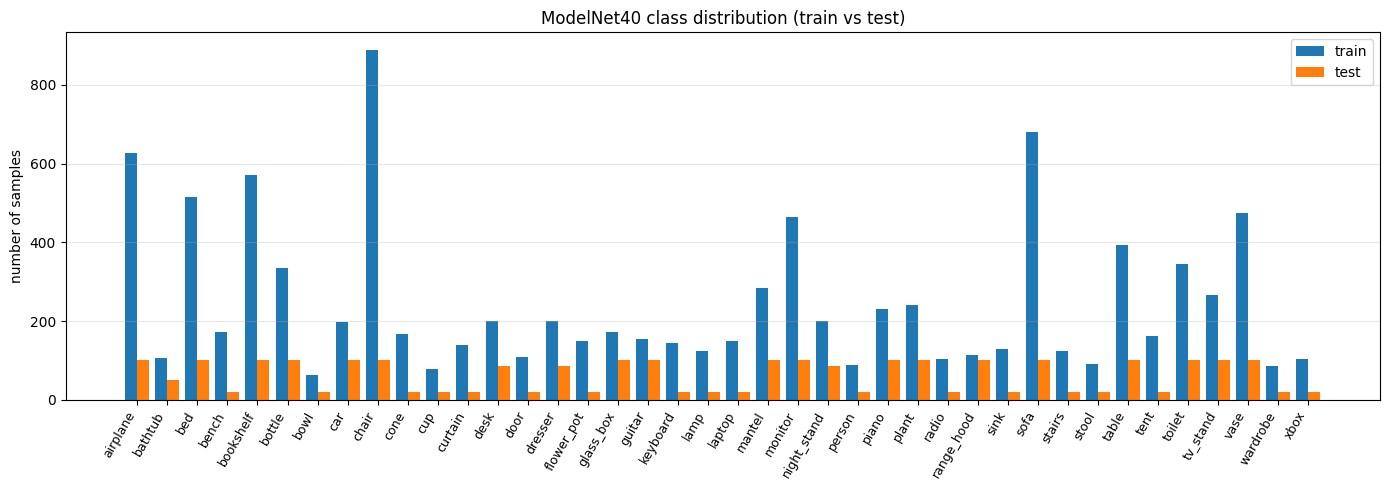

In [3]:
CLASSES_M40 = sorted([
    d for d in os.listdir(DATA_DIR_M40)
    if os.path.isdir(os.path.join(DATA_DIR_M40, d))
    and not d.startswith(("_", "."))
])
CLASS_TO_IDX_M40 = {c: i for i, c in enumerate(CLASSES_M40)}
IDX_TO_CLASS_M40 = {i: c for c, i in CLASS_TO_IDX_M40.items()}

# ---- Count files per class per split ----
print(f"{'idx':>3}  {'class':<14}  {'train':>6}  {'test':>6}  {'total':>6}")
print("-" * 50)

train_counts, test_counts = [], []
for i, c in enumerate(CLASSES_M40):
    train_dir = os.path.join(DATA_DIR_M40, c, "train")
    test_dir  = os.path.join(DATA_DIR_M40, c, "test")
    n_train = len([f for f in os.listdir(train_dir) if f.endswith(".off")]) if os.path.isdir(train_dir) else 0
    n_test  = len([f for f in os.listdir(test_dir)  if f.endswith(".off")]) if os.path.isdir(test_dir)  else 0
    train_counts.append(n_train)
    test_counts.append(n_test)
    print(f"{i:>3}  {c:<14}  {n_train:>6}  {n_test:>6}  {n_train + n_test:>6}")

print("-" * 50)
total_train = sum(train_counts)
total_test  = sum(test_counts)
print(f"{'':>3}  {'TOTAL':<14}  {total_train:>6}  {total_test:>6}  {total_train + total_test:>6}")

# ---- Balance summary ----
min_idx = int(np.argmin(train_counts))
max_idx = int(np.argmax(train_counts))
sorted_counts = sorted(train_counts)
print(f"\nClass balance (train set):")
print(f"  Smallest class : '{CLASSES_M40[min_idx]}' ({min(train_counts)} samples)")
print(f"  Largest class  : '{CLASSES_M40[max_idx]}' ({max(train_counts)} samples)")
print(f"  Mean / median  : {np.mean(train_counts):.0f} / {sorted_counts[20]:.0f}")
print(f"  Imbalance ratio (max / min) : {max(train_counts) / min(train_counts):.1f}x")

# ---- Bar chart of class sizes ----
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(40)
width = 0.4
ax.bar(x - width/2, train_counts, width, label="train")
ax.bar(x + width/2, test_counts,  width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES_M40, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("number of samples")
ax.set_title("ModelNet40 class distribution (train vs test)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

##  Define the ModelNet40 Dataset class and doing a Sanity Check 

In [4]:
import io
import glob
import trimesh


def _safe_load_off(fp):
    """Load an OFF file, fixing the malformed 'OFF<digits>' header bug
    that some ModelNet40 files have (header and counts on the same line).
    """
    with open(fp, "r") as f:
        content = f.read()
    if content.startswith("OFF") and len(content) > 3 and content[3] != "\n":
        # Bad: "OFF684 1180 0\n..."  -> insert newline after OFF
        content = "OFF\n" + content[3:]
        return trimesh.load(io.StringIO(content), file_type="off", force="mesh")
    return trimesh.load(fp, force="mesh")


class ModelNet40Dataset(Dataset):
    """PyTorch Dataset for ModelNet40.

    Walks data/ModelNet40/<class>/<split>/*.off, loads each mesh with trimesh,
    samples `num_points` from the mesh surface, normalizes to a unit sphere
    centered at the origin, and returns (points_tensor, label_int).
    """
    def __init__(self, root, split="train", num_points=1024):
        assert split in {"train", "test"}, "split must be 'train' or 'test'"
        self.root = root
        self.split = split
        self.num_points = num_points

        # Collect (filepath, label) pairs once, sorted for reproducibility
        self.samples = []
        for class_name in CLASSES_M40:
            class_dir = os.path.join(root, class_name, split)
            if not os.path.isdir(class_dir):
                continue
            for fp in sorted(glob.glob(os.path.join(class_dir, "*.off"))):
                self.samples.append((fp, CLASS_TO_IDX_M40[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        mesh = _safe_load_off(fp)
        points, _ = trimesh.sample.sample_surface(mesh, self.num_points)
        points = np.asarray(points, dtype=np.float32)
        # Normalize: center to origin, scale so max radius == 1 (unit sphere)
        points = points - points.mean(axis=0, keepdims=True)
        scale = np.max(np.linalg.norm(points, axis=1))
        points = points / scale
        return torch.from_numpy(points), label


# Instantiate train + test
train_ds_m40 = ModelNet40Dataset(DATA_DIR_M40, split="train", num_points=1024)
test_ds_m40  = ModelNet40Dataset(DATA_DIR_M40, split="test",  num_points=1024)

print(f"Train samples: {len(train_ds_m40)}  (expected 9843)")
print(f"Test samples : {len(test_ds_m40)}   (expected 2468)")

# Sanity check on one training sample
points, label = train_ds_m40[0]
print(f"\n--- Sanity check on train_ds_m40[0] ---")
print(f"  points.shape       : {tuple(points.shape)}     (expected (1024, 3))")
print(f"  points.dtype       : {points.dtype}            (expected torch.float32)")
print(f"  label              : {label}  ({IDX_TO_CLASS_M40[label]})")
print(f"  centered? mean     : {points.mean(0).numpy().round(4)}  (expected ~[0, 0, 0])")
print(f"  unit-sphere? max r : {points.norm(dim=1).max().item():.4f}  (expected 1.0000)")

Train samples: 9843  (expected 9843)
Test samples : 2468   (expected 2468)

--- Sanity check on train_ds_m40[0] ---
  points.shape       : (1024, 3)     (expected (1024, 3))
  points.dtype       : torch.float32            (expected torch.float32)
  label              : 0  (airplane)
  centered? mean     : [ 0.  0. -0.]  (expected ~[0, 0, 0])
  unit-sphere? max r : 1.0000  (expected 1.0000)


## Pre-caching  point clouds 

In [5]:
from tqdm.auto import tqdm


def precache_split_m40(dataset, split_name):
    """Sample every mesh once, save (points, labels) as .npz.
    Skips files that fail to load and logs them.
    """
    cache_path = os.path.join(CACHE_DIR_M40, f"{split_name}.npz")
    if os.path.exists(cache_path):
        size_mb = os.path.getsize(cache_path) / 1024**2
        print(f"Cache for '{split_name}' already exists at {cache_path} ({size_mb:.1f} MB) -- skipping")
        return cache_path

    all_points = []
    all_labels = []
    failed = []

    for i in tqdm(range(len(dataset)), desc=f"Caching {split_name}"):
        try:
            pts, lbl = dataset[i]
            all_points.append(pts.numpy())
            all_labels.append(lbl)
        except Exception as e:
            failed.append((i, dataset.samples[i][0], str(e)))

    points_arr = np.stack(all_points)
    labels_arr = np.array(all_labels, dtype=np.int64)

    if failed:
        print(f"\nWARNING: {len(failed)} / {len(dataset)} files failed to load:")
        for idx, fp, err in failed[:5]:
            print(f"  [{idx}] {os.path.basename(fp)}: {err}")
        if len(failed) > 5:
            print(f"  ... and {len(failed) - 5} more")
        print(f"  These samples are skipped (not in the cache).")

    np.savez(cache_path, points=points_arr, labels=labels_arr)
    size_mb = os.path.getsize(cache_path) / 1024**2
    print(f"\nSaved '{split_name}' cache: shape {points_arr.shape}, {size_mb:.1f} MB")
    return cache_path


print("Pre-caching ModelNet40 (one-time, ~15 min)...\n")
train_cache_path_m40 = precache_split_m40(train_ds_m40, "train")
test_cache_path_m40  = precache_split_m40(test_ds_m40,  "test")
print("\nCaching complete.")

Pre-caching ModelNet40 (one-time, ~15 min)...



Caching train:   0%|          | 0/9843 [00:00<?, ?it/s]

/Users/dosvatsky/3D Object Detection/venv/lib/python3.13/site-packages/trimesh/grouping.py:99: RuntimeWarning: invalid value encountered in cast
  stacked = np.column_stack(stacked).round().astype(np.int64)



Saved 'train' cache: shape (9843, 1024, 3), 115.4 MB


Caching test:   0%|          | 0/2468 [00:00<?, ?it/s]


Saved 'test' cache: shape (2468, 1024, 3), 28.9 MB

Caching complete.


## DataLoading and sample visualization

In [6]:
class CachedModelNet40(Dataset):
    """Reads pre-sampled ModelNet40 point clouds from the .npz cache."""
    def __init__(self, cache_path):
        data = np.load(cache_path)
        self.points = data["points"]   # (n, 1024, 3) float32
        self.labels = data["labels"]   # (n,) int64

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.points[idx]), int(self.labels[idx])


BATCH_SIZE = 32

train_cached_m40 = CachedModelNet40(train_cache_path_m40)
test_cached_m40  = CachedModelNet40(test_cache_path_m40)

# num_workers=0 on macOS (multiprocessing with torch DataLoaders can be flaky on MPS)
train_loader_m40 = DataLoader(train_cached_m40, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=0, drop_last=True)
test_loader_m40  = DataLoader(test_cached_m40,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0)

print(f"Train (cached): {len(train_cached_m40)} samples, {len(train_loader_m40)} batches")
print(f"Test  (cached): {len(test_cached_m40)} samples, {len(test_loader_m40)} batches")

# Timing sanity: pull one batch
start = time.time()
pts, lbls = next(iter(train_loader_m40))
elapsed = time.time() - start

print(f"\n--- One training batch ---")
print(f"  points.shape : {tuple(pts.shape)}    (expected ({BATCH_SIZE}, 1024, 3))")
print(f"  points.dtype : {pts.dtype}")
print(f"  labels.shape : {tuple(lbls.shape)}            (expected ({BATCH_SIZE},))")
print(f"  unique labels in batch: {sorted(set(lbls.tolist()))} ({len(set(lbls.tolist()))} of 40)")
print(f"  load time    : {elapsed*1000:.1f} ms  (vs ~3000 ms uncached)")

Train (cached): 9843 samples, 307 batches
Test  (cached): 2468 samples, 78 batches

--- One training batch ---
  points.shape : (32, 1024, 3)    (expected (32, 1024, 3))
  points.dtype : torch.float32
  labels.shape : (32,)            (expected (32,))
  unique labels in batch: [0, 1, 4, 5, 7, 8, 10, 13, 21, 22, 23, 25, 26, 30, 35, 36] (16 of 40)
  load time    : 41.5 ms  (vs ~3000 ms uncached)


## Visualizing some random samples from random different classes


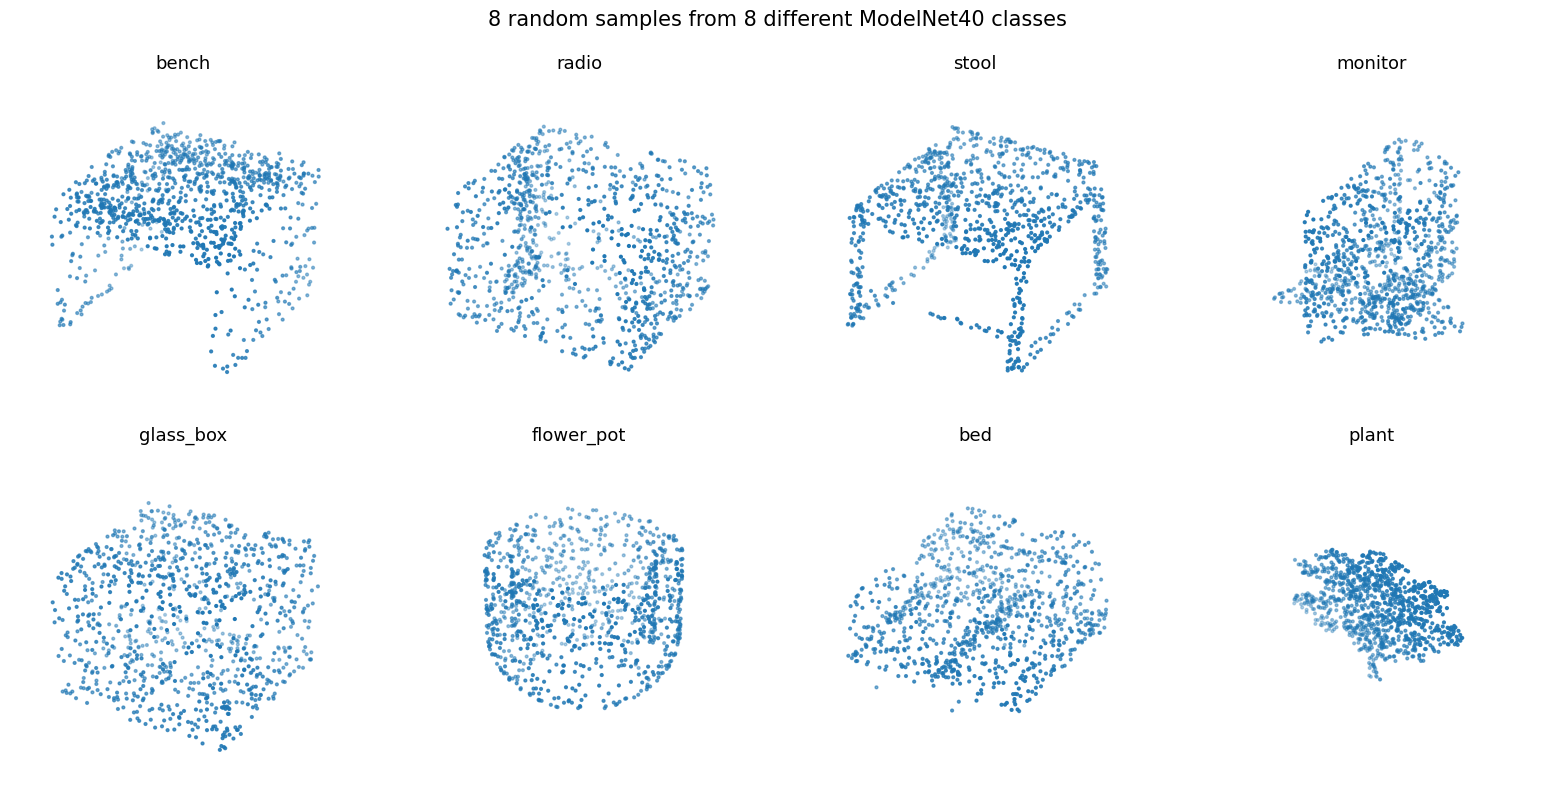

In [7]:
# Pick 8 random distinct classes, then pick one random sample from each
rng = np.random.default_rng(42)
chosen_classes = rng.choice(40, size=8, replace=False)

sample_indices = []
sample_labels = []
for cls in chosen_classes:
    cls_indices = np.where(train_cached_m40.labels == cls)[0]
    pick = rng.choice(cls_indices)
    sample_indices.append(int(pick))
    sample_labels.append(int(cls))

fig = plt.figure(figsize=(16, 8))
for plot_i, (idx, lbl) in enumerate(zip(sample_indices, sample_labels)):
    pts = train_cached_m40.points[idx]
    ax = fig.add_subplot(2, 4, plot_i + 1, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=4)
    ax.set_title(f"{IDX_TO_CLASS_M40[lbl]}", fontsize=13)
    ax.set_axis_off()
plt.suptitle("8 random samples from 8 different ModelNet40 classes", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

## Defining PointNet v1 (no T-Net) for all 40 classes


In [8]:
class PointNetV1(nn.Module):
    """Minimal PointNet classifier — no T-Net, no feature transform.

    Architecture (identical to ModelNet10 version, only num_classes default differs):
        Input            (B, N, 3)
        → permute to     (B, 3, N)
        → shared MLP (64, 64, 64, 128, 1024)  — Conv1d with kernel_size=1
        → global max-pool over N              → (B, 1024)
        → classifier (512, 256, num_classes)  → (B, num_classes)
    """
    def __init__(self, num_classes=40):
        super().__init__()
        self.shared_mlp = nn.Sequential(
            nn.Conv1d(3,   64,   kernel_size=1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  64,   kernel_size=1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  64,   kernel_size=1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  128,  kernel_size=1), nn.BatchNorm1d(128),  nn.ReLU(),
            nn.Conv1d(128, 1024, kernel_size=1), nn.BatchNorm1d(1024), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256,  num_classes),
        )

    def forward(self, x):
        # x: (B, N, 3) -> permute to (B, 3, N) for Conv1d
        x = x.transpose(1, 2)         # (B, 3, N)
        x = self.shared_mlp(x)        # (B, 1024, N)
        x = torch.max(x, dim=2)[0]    # (B, 1024) — global max-pool
        x = self.classifier(x)        # (B, num_classes)
        return x


# Instantiate for 40 classes and inspect
model = PointNetV1(num_classes=40).to(device)
n_mlp        = sum(p.numel() for p in model.shared_mlp.parameters())
n_classifier = sum(p.numel() for p in model.classifier.parameters())
n_total      = sum(p.numel() for p in model.parameters())

print("Model: PointNet v1 vanilla (paper Table 5 baseline, target 87.1%)\n")
print("Parameter count by block:")
print(f"  shared per-point MLP : {n_mlp:>9,}")
print(f"  classifier head      : {n_classifier:>9,}")
print(f"  {'-'*36}")
print(f"  total                : {n_total:>9,}    (ModelNet10 v1 was 811,914)")

# Forward sanity check on one real batch on the chosen device
pts, lbls = next(iter(train_loader_m40))
pts, lbls = pts.to(device), lbls.to(device)
with torch.no_grad():
    out = model(pts)
print(f"\nForward sanity:")
print(f"  input  shape : {tuple(pts.shape)}")
print(f"  output shape : {tuple(out.shape)}  (expected (32, 40))")
print(f"  finite?      : {torch.isfinite(out).all().item()}")
print(f"  logits range : [{out.min().item():.3f}, {out.max().item():.3f}]")

Model: PointNet v1 vanilla (paper Table 5 baseline, target 87.1%)

Parameter count by block:
  shared per-point MLP :   151,680
  classifier head      :   667,944
  ------------------------------------
  total                :   819,624    (ModelNet10 v1 was 811,914)

Forward sanity:
  input  shape : (32, 1024, 3)
  output shape : (32, 40)  (expected (32, 40))
  finite?      : True
  logits range : [-1.646, 1.261]


## Training v1 on ModelNet40 for 20 epochs

Training PointNet v1 vanilla on ModelNet40 — 20 epochs on mps
Paper target (Table 5 baseline): 87.1%

epoch   train_loss   train_acc    val_acc     time
-------------------------------------------------------
    1       1.0957      0.7047     0.7010    63.7s  *
    2       0.6338      0.8020     0.7374    67.1s  *
    3       0.5241      0.8339     0.7848    58.4s  *
    4       0.4678      0.8497     0.7156    62.9s
    5       0.4188      0.8606     0.8071    56.8s  *
    6       0.3900      0.8725     0.8006    60.2s
    7       0.3612      0.8811     0.8262    55.4s  *
    8       0.3309      0.8896     0.8104    63.5s
    9       0.3233      0.8890     0.8241    59.5s
   10       0.2915      0.9020     0.8347    62.5s  *
   11       0.2727      0.9093     0.8254    68.6s
   12       0.2660      0.9055     0.8233    60.8s
   13       0.2468      0.9142     0.8420    58.0s  *
   14       0.2403      0.9153     0.8323    60.0s
   15       0.2230      0.9197     0.8173    56.7s
   16

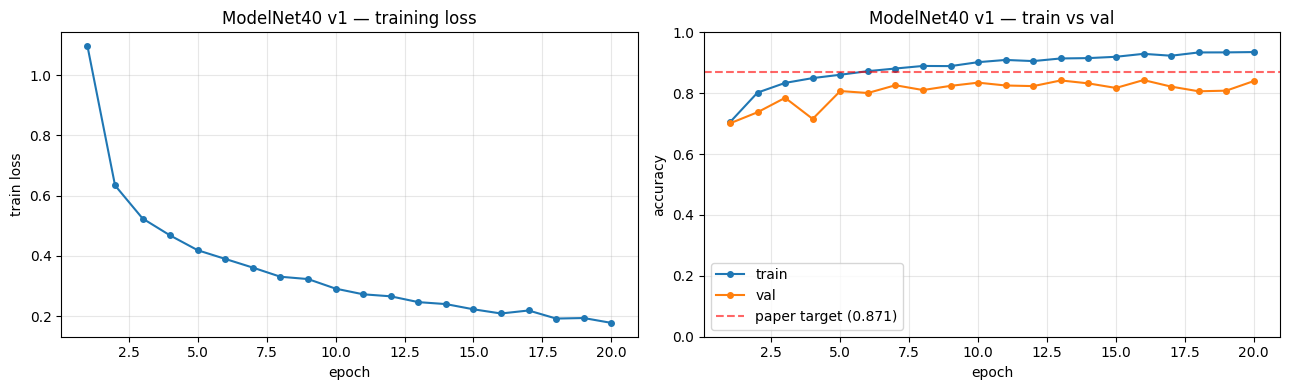

In [9]:
best_path_v1_m40 = os.path.join(CHECKPOINT_DIR, "pointnet_v1_modelnet40_best.pt")

# Fresh model + optimizer
model = PointNetV1(num_classes=40).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 20
history_v1_m40 = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

print(f"Training PointNet v1 vanilla on ModelNet40 — {NUM_EPOCHS} epochs on {device}")
print(f"Paper target (Table 5 baseline): 87.1%\n")
print(f"{'epoch':>5}  {'train_loss':>11}  {'train_acc':>10}  {'val_acc':>9}  {'time':>7}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ---- Train ----
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for pts, lbls in train_loader_m40:
        pts, lbls = pts.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(pts)
        loss = F.cross_entropy(logits, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * pts.size(0)
        correct  += (logits.argmax(1) == lbls).sum().item()
        total    += pts.size(0)
    train_loss = loss_sum / total
    train_acc  = correct  / total

    # ---- Validate ----
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for pts, lbls in test_loader_m40:
            pts, lbls = pts.to(device), lbls.to(device)
            val_correct += (model(pts).argmax(1) == lbls).sum().item()
            val_total   += pts.size(0)
    val_acc = val_correct / val_total

    history_v1_m40["train_loss"].append(train_loss)
    history_v1_m40["train_acc"].append(train_acc)
    history_v1_m40["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path_v1_m40)
        flag = "  *"

    print(f"{epoch:>5}  {train_loss:>11.4f}  {train_acc:>10.4f}  {val_acc:>9.4f}  {time.time()-t0:>6.1f}s{flag}")

print(f"\n=== Result ===")
print(f"  Best val_acc on ModelNet40 : {best_val_acc:.4f}")
print(f"  Paper target (Table 5)     : 0.8710")
print(f"  Gap to paper               : {best_val_acc - 0.871:+.4f}")
print(f"  Checkpoint                 : {best_path_v1_m40}")

# Plot loss + accuracy curves with paper-target reference
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, NUM_EPOCHS + 1)
ax1.plot(ep, history_v1_m40["train_loss"], "-o", markersize=4)
ax1.set(xlabel="epoch", ylabel="train loss", title="ModelNet40 v1 — training loss")
ax1.grid(alpha=0.3)

ax2.plot(ep, history_v1_m40["train_acc"], "-o", markersize=4, label="train")
ax2.plot(ep, history_v1_m40["val_acc"],   "-o", markersize=4, label="val")
ax2.axhline(0.871, color="red", linestyle="--", alpha=0.6, label="paper target (0.871)")
ax2.set(xlabel="epoch", ylabel="accuracy", title="ModelNet40 v1 — train vs val", ylim=(0, 1))
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

##  Retraining v1 with Augmentation and L-R Scheduling 

In [10]:
class AugmentedCachedModelNet40(Dataset):
    """Cached ModelNet40 with optional on-the-fly augmentation.
    augment=True applies random z-rotation + per-point Gaussian jitter (train).
    augment=False returns clean samples (test).
    """
    def __init__(self, cache_path, augment=False, jitter_sigma=0.02, jitter_clip=0.05):
        data = np.load(cache_path)
        self.points = data["points"]
        self.labels = data["labels"]
        self.augment = augment
        self.jitter_sigma = jitter_sigma
        self.jitter_clip = jitter_clip

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        pts = self.points[idx].copy()
        if self.augment:
            # 1. Random z-axis rotation
            theta = np.random.uniform(0, 2 * np.pi)
            c, s = np.cos(theta), np.sin(theta)
            R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
            pts = pts @ R.T
            # 2. Per-point Gaussian jitter, clipped
            jitter = np.random.normal(0, self.jitter_sigma, pts.shape).astype(np.float32)
            jitter = np.clip(jitter, -self.jitter_clip, self.jitter_clip)
            pts = pts + jitter
        return torch.from_numpy(pts), int(self.labels[idx])


# Augmented train + clean test
train_aug_m40   = AugmentedCachedModelNet40(train_cache_path_m40, augment=True)
test_clean_m40  = AugmentedCachedModelNet40(test_cache_path_m40,  augment=False)

train_loader_m40 = DataLoader(train_aug_m40,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
test_loader_m40  = DataLoader(test_clean_m40, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train (augmented): {len(train_aug_m40)} samples, {len(train_loader_m40)} batches")
print(f"Test  (clean)    : {len(test_clean_m40)} samples, {len(test_loader_m40)} batches")

Train (augmented): 9843 samples, 307 batches
Test  (clean)    : 2468 samples, 78 batches


## Training v1 with augmentation + cosine LR schedule for 40 epochs

Training PointNet v1 with paper recipe -- 40 epochs on mps
Augmentation: z-rotation + jitter (sigma=0.02, clip=0.05)
LR schedule : cosine decay from 1e-3 to 1e-5
Paper target: 0.871

epoch        lr   train_loss   train_acc    val_acc     time
----------------------------------------------------------------
    1  1.00e-03       1.4366      0.5947     0.5527    59.0s  *
    2  9.98e-04       0.8969      0.7310     0.6754    59.2s  *
    3  9.94e-04       0.7749      0.7572     0.7439    63.4s  *
    4  9.86e-04       0.7091      0.7743     0.7107    70.1s
    5  9.76e-04       0.6695      0.7903     0.7382    64.6s
    6  9.62e-04       0.6288      0.8029     0.7654    64.6s  *
    7  9.46e-04       0.5830      0.8131     0.7853    59.9s  *
    8  9.27e-04       0.5500      0.8202     0.7885    60.4s  *
    9  9.05e-04       0.5357      0.8287     0.7776    68.6s
   10  8.81e-04       0.4975      0.8367     0.7921    63.6s  *
   11  8.55e-04       0.4850      0.8408     0.8002    65.0s

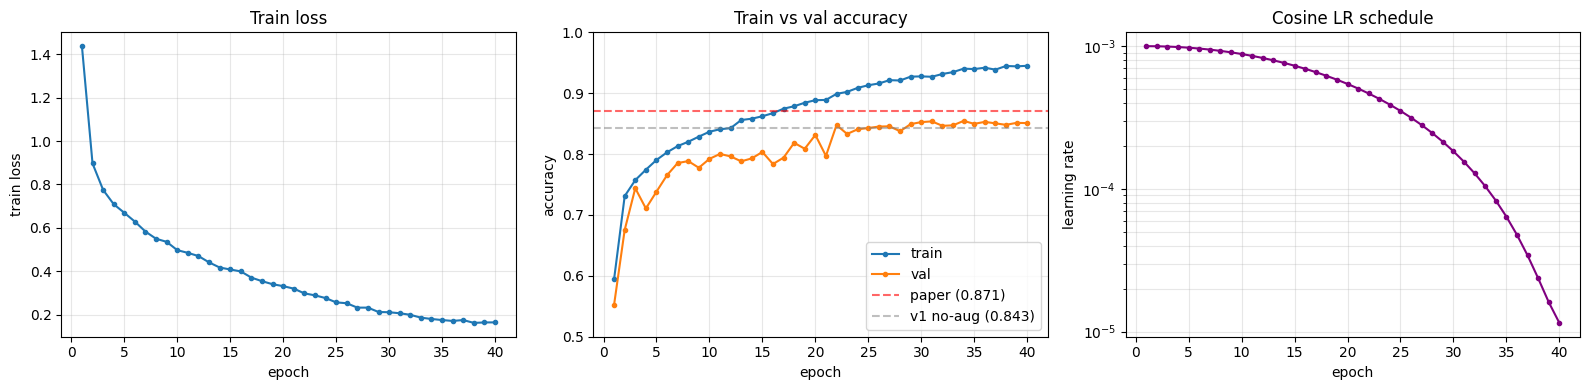

In [11]:
best_path_v1_m40_aug = os.path.join(CHECKPOINT_DIR, "pointnet_v1_modelnet40_aug_best.pt")

# Fresh model + optimizer + cosine schedule
model = PointNetV1(num_classes=40).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 40
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

history_v1_m40_aug = {"train_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_acc = 0.0

print(f"Training PointNet v1 with paper recipe -- {NUM_EPOCHS} epochs on {device}")
print(f"Augmentation: z-rotation + jitter (sigma=0.02, clip=0.05)")
print(f"LR schedule : cosine decay from 1e-3 to 1e-5")
print(f"Paper target: 0.871\n")
print(f"{'epoch':>5}  {'lr':>8}  {'train_loss':>11}  {'train_acc':>10}  {'val_acc':>9}  {'time':>7}")
print("-" * 64)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer.param_groups[0]["lr"]

    # ---- Train ----
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for pts, lbls in train_loader_m40:
        pts, lbls = pts.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(pts)
        loss = F.cross_entropy(logits, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * pts.size(0)
        correct  += (logits.argmax(1) == lbls).sum().item()
        total    += pts.size(0)
    scheduler.step()  # step the LR schedule once per epoch
    train_loss = loss_sum / total
    train_acc  = correct  / total

    # ---- Validate ----
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for pts, lbls in test_loader_m40:
            pts, lbls = pts.to(device), lbls.to(device)
            val_correct += (model(pts).argmax(1) == lbls).sum().item()
            val_total   += pts.size(0)
    val_acc = val_correct / val_total

    history_v1_m40_aug["train_loss"].append(train_loss)
    history_v1_m40_aug["train_acc"].append(train_acc)
    history_v1_m40_aug["val_acc"].append(val_acc)
    history_v1_m40_aug["lr"].append(current_lr)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path_v1_m40_aug)
        flag = "  *"

    print(f"{epoch:>5}  {current_lr:>8.2e}  {train_loss:>11.4f}  {train_acc:>10.4f}  {val_acc:>9.4f}  {time.time()-t0:>6.1f}s{flag}")

print(f"\n=== Result ===")
print(f"  Best val_acc (v1 + aug + cosine LR) : {best_val_acc:.4f}")
print(f"  Paper target (Table 5 baseline)     : 0.8710")
print(f"  Gap to paper                        : {best_val_acc - 0.871:+.4f}")
print(f"  Previous v1 (no aug)                : 0.8432  (delta {best_val_acc - 0.8432:+.4f})")
print(f"  Checkpoint                          : {best_path_v1_m40_aug}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, NUM_EPOCHS + 1)
axes[0].plot(ep, history_v1_m40_aug["train_loss"], "-o", markersize=3)
axes[0].set(xlabel="epoch", ylabel="train loss", title="Train loss")
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history_v1_m40_aug["train_acc"], "-o", markersize=3, label="train")
axes[1].plot(ep, history_v1_m40_aug["val_acc"],   "-o", markersize=3, label="val")
axes[1].axhline(0.871, color="red", linestyle="--", alpha=0.6, label="paper (0.871)")
axes[1].axhline(0.8432, color="gray", linestyle="--", alpha=0.5, label="v1 no-aug (0.843)")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="Train vs val accuracy", ylim=(0.5, 1.0))
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history_v1_m40_aug["lr"], "-o", markersize=3, color="purple")
axes[2].set(xlabel="epoch", ylabel="learning rate", title="Cosine LR schedule", yscale="log")
axes[2].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Per-class evaluation of v1 on ModelNet40 

OVERALL METRICS — v1 on ModelNet40
  Accuracy     : 0.8545   (paper baseline target: 0.8710)
  Macro F1     : 0.8082   (paper class-avg target: 0.862)
  Weighted F1  : 0.8551
  Gap to paper acc : -0.0165

PER-CLASS METRICS (all 40 classes)
              precision    recall  f1-score   support

    airplane      0.990     1.000     0.995       100
     bathtub      0.949     0.740     0.831        50
         bed      0.890     0.970     0.928       100
       bench      0.577     0.750     0.652        20
   bookshelf      0.791     0.870     0.829       100
      bottle      0.949     0.940     0.945       100
        bowl      0.826     0.950     0.884        20
         car      0.990     0.970     0.980       100
       chair      0.906     0.960     0.932       100
        cone      0.905     0.950     0.927        20
         cup      0.571     0.600     0.585        20
     curtain      0.714     0.750     0.732        20
        desk      0.780     0.744     0.762        86
   

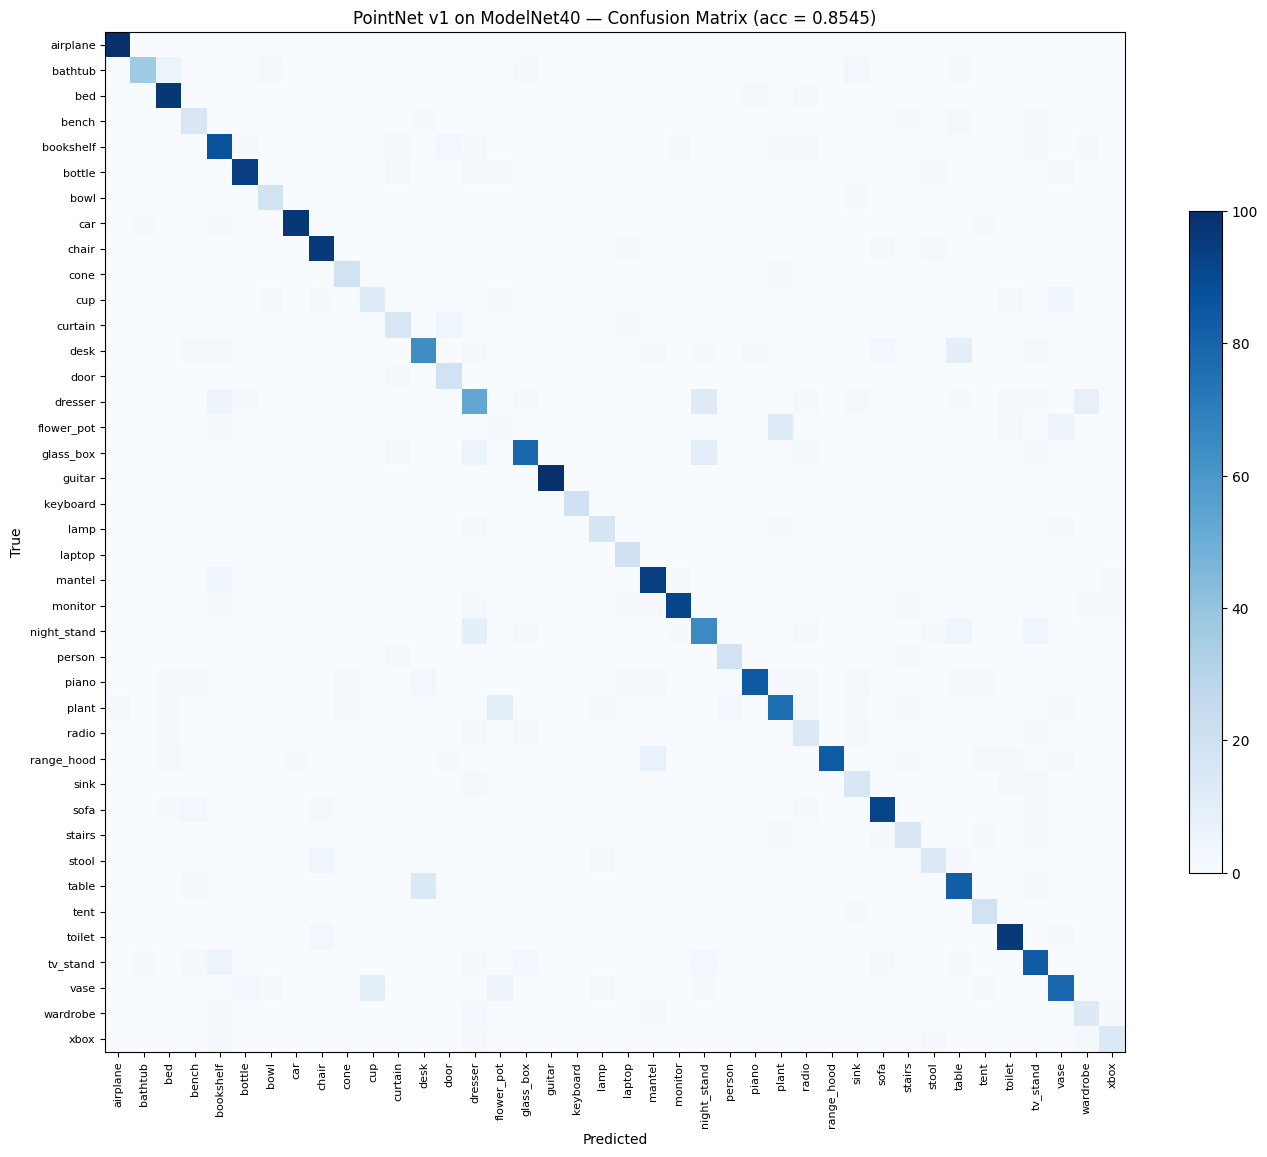

In [12]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_recall_fscore_support,
)

# Load best v1 checkpoint
model = PointNetV1(num_classes=40).to(device)
model.load_state_dict(torch.load(best_path_v1_m40_aug, map_location=device, weights_only=True))
model.eval()

# Inference on full test set
all_preds, all_labels = [], []
with torch.no_grad():
    for pts, lbls in test_loader_m40:
        pts = pts.to(device)
        preds = model(pts).argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(lbls.numpy())
all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# ---- 1. Overall metrics ----
acc         = accuracy_score(all_labels, all_preds)
macro_f1    = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("=" * 60)
print("OVERALL METRICS — v1 on ModelNet40")
print("=" * 60)
print(f"  Accuracy     : {acc:.4f}   (paper baseline target: 0.8710)")
print(f"  Macro F1     : {macro_f1:.4f}   (paper class-avg target: 0.862)")
print(f"  Weighted F1  : {weighted_f1:.4f}")
print(f"  Gap to paper acc : {acc - 0.871:+.4f}")

# ---- 2. Full per-class table ----
print("\n" + "=" * 60)
print("PER-CLASS METRICS (all 40 classes)")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASSES_M40, digits=3))

# ---- 3. Class coverage check ----
predicted_classes = set(all_preds.tolist())
missing = set(range(40)) - predicted_classes
print("=" * 60)
print("CLASS COVERAGE CHECK")
print("=" * 60)
print(f"  Distinct classes predicted: {len(predicted_classes)}/40")
if missing:
    print(f"  MISSING: {[CLASSES_M40[i] for i in sorted(missing)]}")
    print(f"  GATE FAILED")
else:
    print(f"  GATE PASSED — every class predicted at least once")

# ---- 4. Best/worst classes by F1 ----
_, _, f1_per_class, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=list(range(40)), zero_division=0
)
ranked = sorted(zip(f1_per_class, CLASSES_M40, support), reverse=True)

print("\n" + "=" * 60)
print("TOP 5 BEST CLASSES (by F1)")
print("=" * 60)
for f1, name, supp in ranked[:5]:
    print(f"  {name:<14}  F1 = {f1:.4f}   (support={supp})")

print("\n" + "=" * 60)
print("BOTTOM 5 WORST CLASSES (by F1)")
print("=" * 60)
for f1, name, supp in ranked[-5:][::-1]:
    print(f"  {name:<14}  F1 = {f1:.4f}   (support={supp})")

# ---- 5. Top confusion pairs ----
cm = confusion_matrix(all_labels, all_preds, labels=list(range(40)))
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
print("\n" + "=" * 60)
print("TOP 10 CONFUSION PAIRS (off-diagonal)")
print("=" * 60)
flat = [(cm_off[i, j], CLASSES_M40[i], CLASSES_M40[j]) for i in range(40) for j in range(40)]
flat.sort(reverse=True)
for count, true_c, pred_c in flat[:10]:
    if count == 0: break
    print(f"  {true_c:>13}  ->  {pred_c:<13}  : {count} misclassified")

# ---- 6. 40x40 Confusion matrix heatmap ----
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(40)); ax.set_yticks(range(40))
ax.set_xticklabels(CLASSES_M40, rotation=90, fontsize=8)
ax.set_yticklabels(CLASSES_M40, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"PointNet v1 on ModelNet40 — Confusion Matrix (acc = {acc:.4f})")
plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

## Defining TNet + PointNetV2 + train on ModelNet40

In [13]:
class TNet(nn.Module):
    """Spatial transformer for point clouds — predicts a k×k affine matrix.
    Initialized to output identity so the model behaves like plain PointNet at init.
    """
    def __init__(self, k=3):
        super().__init__()
        self.k = k
        self.shared_mlp = nn.Sequential(
            nn.Conv1d(k,   64,   1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  128,  1), nn.BatchNorm1d(128),  nn.ReLU(),
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256,  k * k),
        )
        # Identity init: final layer outputs vec(I_k)
        nn.init.zeros_(self.head[-1].weight)
        nn.init.zeros_(self.head[-1].bias)
        with torch.no_grad():
            self.head[-1].bias.copy_(torch.eye(k).flatten())

    def forward(self, x):
        B = x.size(0)
        x = x.transpose(1, 2)
        x = self.shared_mlp(x)
        x = torch.max(x, dim=2)[0]
        x = self.head(x)
        return x.view(B, self.k, self.k)


class PointNetV2(nn.Module):
    """PointNet v2: v1 + input T-Net (3×3 spatial transform applied to points before main MLP)."""
    def __init__(self, num_classes=40):
        super().__init__()
        self.input_tnet = TNet(k=3)
        self.shared_mlp = nn.Sequential(
            nn.Conv1d(3,   64,   1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  64,   1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  64,   1), nn.BatchNorm1d(64),   nn.ReLU(),
            nn.Conv1d(64,  128,  1), nn.BatchNorm1d(128),  nn.ReLU(),
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512,  256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256,  num_classes),
        )

    def forward(self, x):
        T = self.input_tnet(x)              # (B, 3, 3)
        x = torch.bmm(x, T)                 # apply transform
        x = x.transpose(1, 2)
        x = self.shared_mlp(x)
        x = torch.max(x, dim=2)[0]
        x = self.classifier(x)
        return x


# Verify T-Net outputs identity at init
_tnet = TNet(k=3)
with torch.no_grad():
    T = _tnet(torch.randn(2, 1024, 3))
print("T-Net output at init (should be identity):")
print(T[0].numpy().round(4))

# Instantiate v2 and inspect
model = PointNetV2(num_classes=40).to(device)
n_tnet       = sum(p.numel() for p in model.input_tnet.parameters())
n_mlp        = sum(p.numel() for p in model.shared_mlp.parameters())
n_classifier = sum(p.numel() for p in model.classifier.parameters())
n_total      = sum(p.numel() for p in model.parameters())
print(f"\nPointNet v2 (input T-Net) — parameters:")
print(f"  T-Net               : {n_tnet:>9,}")
print(f"  shared MLP          : {n_mlp:>9,}")
print(f"  classifier          : {n_classifier:>9,}")
print(f"  total               : {n_total:>9,}    ({n_total/819624:.2f}x v1)")

# Forward sanity
pts, lbls = next(iter(train_loader_m40))
pts, lbls = pts.to(device), lbls.to(device)
with torch.no_grad():
    out = model(pts)
print(f"\nForward sanity: output {tuple(out.shape)}, finite={torch.isfinite(out).all().item()}")

T-Net output at init (should be identity):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

PointNet v2 (input T-Net) — parameters:
  T-Net               :   803,081
  shared MLP          :   151,680
  classifier          :   667,944
  total               : 1,622,705    (1.98x v1)

Forward sanity: output (32, 40), finite=True


## Training v2 (aug + cosine LR + 40 epochs) on ModelNet40

Training PointNet v2 (+ input T-Net) on ModelNet40 -- 40 epochs on mps
Recipe: same as v1 (z-rot + jitter aug, cosine LR 1e-3 -> 1e-5)
Targets: v1 was 0.8545,  paper says +0.3% from input T-Net (target ~0.87)

epoch        lr   train_loss   train_acc    val_acc     time
----------------------------------------------------------------
    1  1.00e-03       1.5343      0.5728     0.5515   110.2s  *
    2  9.98e-04       0.9112      0.7239     0.7216   118.6s  *
    3  9.94e-04       0.7723      0.7599     0.7306   118.4s  *
    4  9.86e-04       0.6893      0.7830     0.7301   114.8s
    5  9.76e-04       0.6563      0.7908     0.7658   124.1s  *
    6  9.62e-04       0.5924      0.8115     0.7536   119.1s
    7  9.46e-04       0.5814      0.8161     0.8096   120.2s  *
    8  9.27e-04       0.5391      0.8256     0.7613   119.3s
    9  9.05e-04       0.5054      0.8336     0.7848   124.1s
   10  8.81e-04       0.4865      0.8399     0.8193   120.3s  *
   11  8.55e-04       0.4729      0.

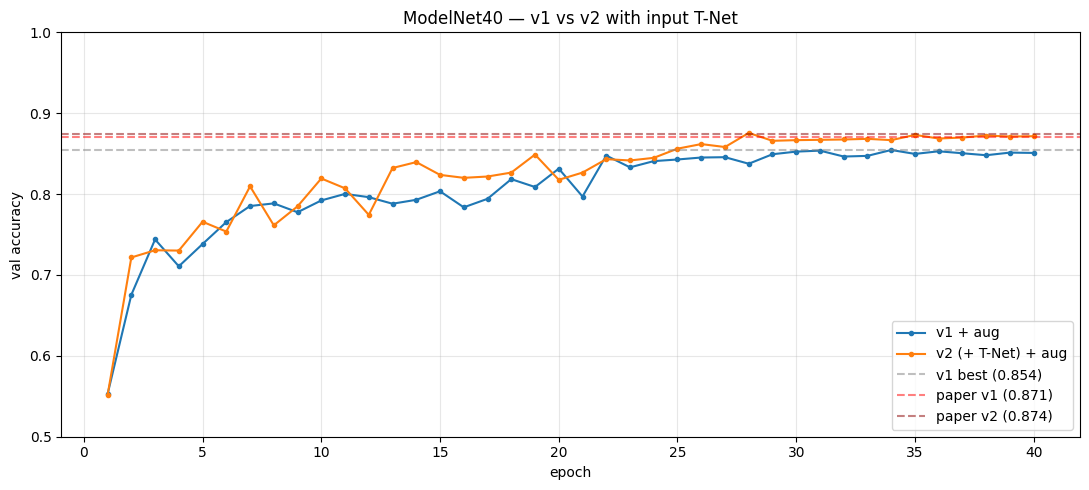

In [14]:
best_path_v2_m40 = os.path.join(CHECKPOINT_DIR, "pointnet_v2_modelnet40_aug_best.pt")

# Fresh model + optimizer + scheduler (identical to v1 setup)
model = PointNetV2(num_classes=40).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 40
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

history_v2_m40 = {"train_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_acc_v2 = 0.0

print(f"Training PointNet v2 (+ input T-Net) on ModelNet40 -- {NUM_EPOCHS} epochs on {device}")
print(f"Recipe: same as v1 (z-rot + jitter aug, cosine LR 1e-3 -> 1e-5)")
print(f"Targets: v1 was 0.8545,  paper says +0.3% from input T-Net (target ~0.87)\n")
print(f"{'epoch':>5}  {'lr':>8}  {'train_loss':>11}  {'train_acc':>10}  {'val_acc':>9}  {'time':>7}")
print("-" * 64)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer.param_groups[0]["lr"]

    # ---- Train ----
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for pts, lbls in train_loader_m40:
        pts, lbls = pts.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(pts)
        loss = F.cross_entropy(logits, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * pts.size(0)
        correct  += (logits.argmax(1) == lbls).sum().item()
        total    += pts.size(0)
    scheduler.step()
    train_loss = loss_sum / total
    train_acc  = correct  / total

    # ---- Validate ----
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for pts, lbls in test_loader_m40:
            pts, lbls = pts.to(device), lbls.to(device)
            val_correct += (model(pts).argmax(1) == lbls).sum().item()
            val_total   += pts.size(0)
    val_acc = val_correct / val_total

    history_v2_m40["train_loss"].append(train_loss)
    history_v2_m40["train_acc"].append(train_acc)
    history_v2_m40["val_acc"].append(val_acc)
    history_v2_m40["lr"].append(current_lr)

    flag = ""
    if val_acc > best_val_acc_v2:
        best_val_acc_v2 = val_acc
        torch.save(model.state_dict(), best_path_v2_m40)
        flag = "  *"

    print(f"{epoch:>5}  {current_lr:>8.2e}  {train_loss:>11.4f}  {train_acc:>10.4f}  {val_acc:>9.4f}  {time.time()-t0:>6.1f}s{flag}")

print(f"\n=== Result ===")
print(f"  v1 baseline (aug)       : 0.8545")
print(f"  v2 (+ input T-Net, aug) : {best_val_acc_v2:.4f}   (delta vs v1: {best_val_acc_v2 - 0.8545:+.4f})")
print(f"  Paper target            : 0.8740   (gap: {best_val_acc_v2 - 0.874:+.4f})")
print(f"  Checkpoint              : {best_path_v2_m40}")

# Plot v1 vs v2 on the same axes
fig, ax = plt.subplots(figsize=(11, 5))
ep = range(1, NUM_EPOCHS + 1)
ax.plot(ep, history_v1_m40_aug["val_acc"], "-o", markersize=3, label="v1 + aug")
ax.plot(ep, history_v2_m40["val_acc"],     "-o", markersize=3, label="v2 (+ T-Net) + aug")
ax.axhline(0.8545, color="gray", linestyle="--", alpha=0.5, label="v1 best (0.854)")
ax.axhline(0.871,  color="red",  linestyle="--", alpha=0.5, label="paper v1 (0.871)")
ax.axhline(0.874,  color="darkred", linestyle="--", alpha=0.5, label="paper v2 (0.874)")
ax.set(xlabel="epoch", ylabel="val accuracy", title="ModelNet40 — v1 vs v2 with input T-Net", ylim=(0.5, 1.0))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()